# Fourier Analysis & Spectral Methods

**Navigation**: [← Previous: Holt-Winters](03_holt_winters.ipynb) | [Next: ARMA & ARIMA →](05_arma_arima.ipynb)

Fourier analysis decomposes a series into sinusoids at different frequencies, revealing periodic structure and enabling flexible seasonal regression.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

DATA_DIR = Path('data')
if not DATA_DIR.exists():
    DATA_DIR = Path('projects/time-series-analysis/data')

def load_series(name):
    """Load a bundled CSV as a DatetimeIndex Series."""
    df = pd.read_csv(DATA_DIR / name, parse_dates=['date'])
    return df.set_index('date')['value'].sort_index()

def load_air_passengers():
    path = DATA_DIR / 'air_passengers.csv'
    if path.exists():
        return load_series('air_passengers.csv')
    from statsmodels.datasets import get_rdataset
    air = get_rdataset('AirPassengers', 'datasets').data
    s = air['value']
    s.index = pd.date_range('1949-01', periods=len(s), freq='MS')
    return s

def load_milk():
    path = DATA_DIR / 'monthly_milk.csv'
    if path.exists():
        return load_series('monthly_milk.csv')
    url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-milk-production-pounds.csv'
    return pd.read_csv(url, index_col=0, parse_dates=True).squeeze()

def load_co2():
    from statsmodels.datasets import co2
    return co2.load().data.resample('MS').mean().ffill().squeeze()

def load_sunspots():
    from statsmodels.datasets import sunspots
    d = sunspots.load_pandas().data
    return d.set_index('YEAR')['SUNACTIVITY']

def load_retail():
    path = DATA_DIR / 'uk_retail_sales.csv'
    if path.exists():
        return load_series('uk_retail_sales.csv')
    raise FileNotFoundError('uk_retail_sales.csv not found in data/')
import statsmodels.formula.api as smf
from scipy.signal import welch, periodogram

## Discrete Fourier Transform

The DFT maps a series to frequency domain: $X_k = \sum_{t=0}^{N-1} x_t e^{-2\pi i k t / N}$.

In [2]:

def manual_dft(x):
    N = len(x)
    k = np.arange(N // 2 + 1)
    t = np.arange(N)
    return np.array([np.sum(x * np.exp(-2j * np.pi * k_i * t / N)) for k_i in k])

co2 = load_co2().dropna().values[-120:]  # last 10 years
dft_manual = manual_dft(co2 - co2.mean())
dft_numpy = np.fft.rfft(co2 - co2.mean())
np.allclose(np.abs(dft_manual), np.abs(dft_numpy), rtol=1e-10)


True

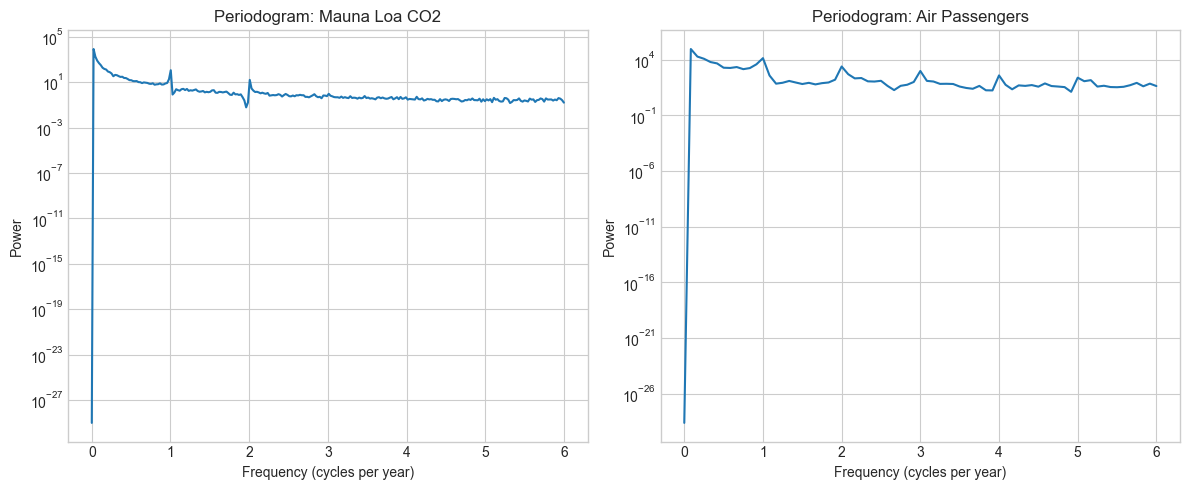

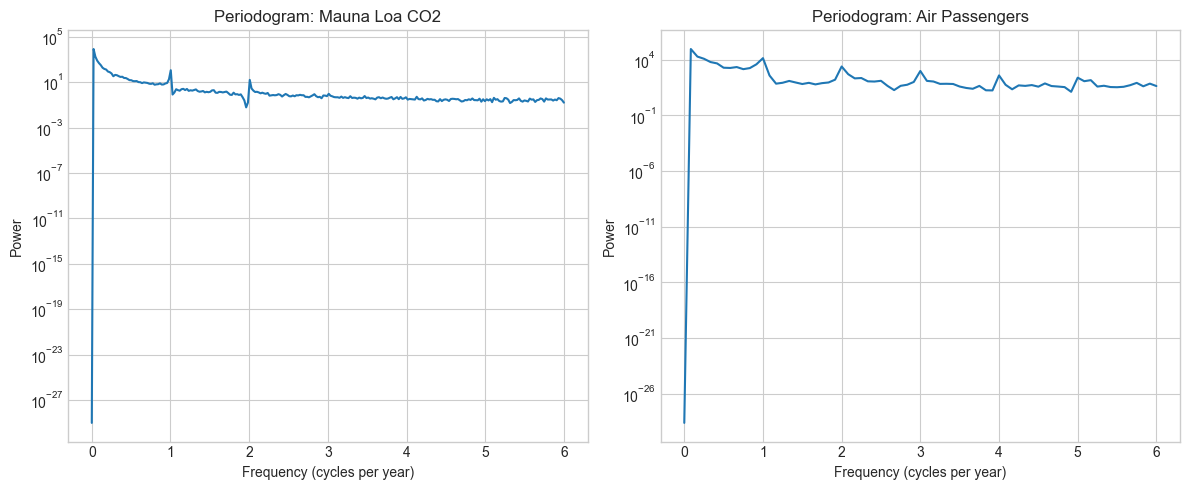

In [3]:

# Periodogram of CO2 and Air Passengers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (s, title) in zip(axes, [(load_co2().dropna(), 'Mauna Loa CO2'), (load_air_passengers(), 'Air Passengers')]):
    y = s.values - s.values.mean()
    freqs, psd = periodogram(y, fs=12 if 'CO2' in title or 'Passengers' in title else 1)
    ax.semilogy(freqs, psd)
    ax.set_title(f'Periodogram: {title}')
    ax.set_xlabel('Frequency (cycles per year)')
    ax.set_ylabel('Power')
fig.tight_layout()
fig


## Welch's Method

Windowing (Hann) reduces spectral leakage compared to the raw periodogram.

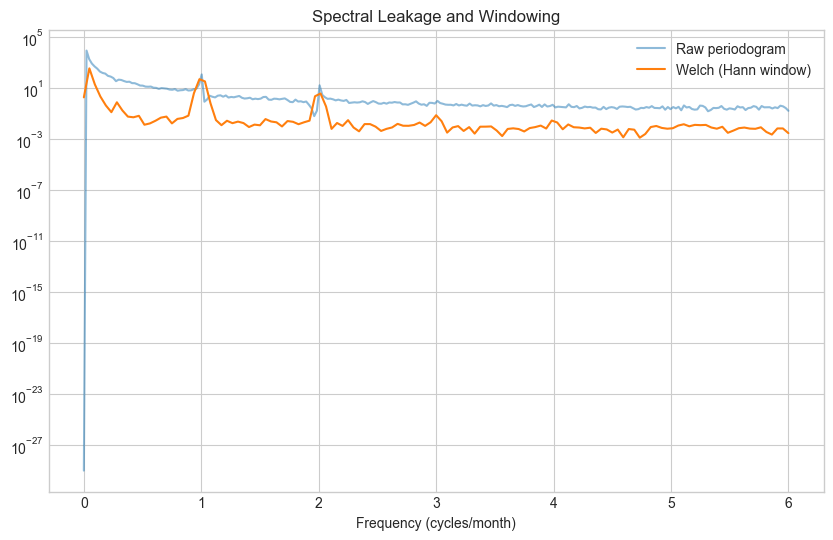

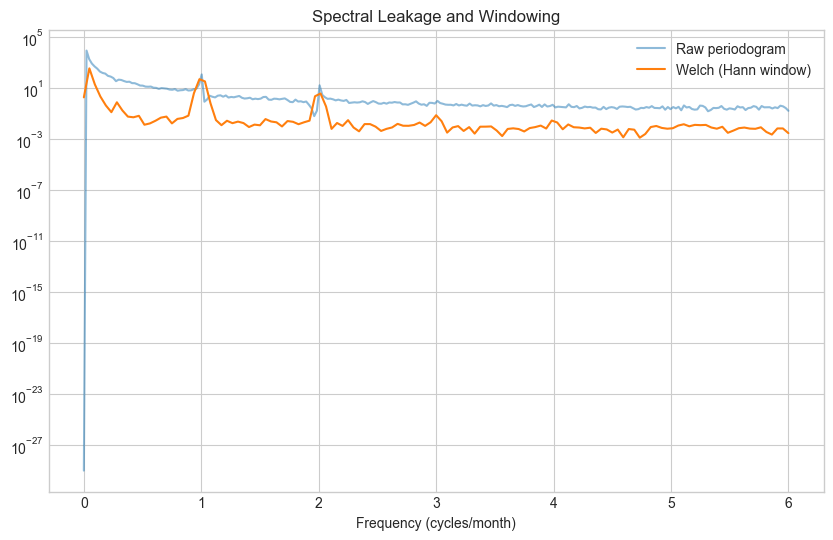

In [4]:

co2_vals = load_co2().dropna().values
f_raw, p_raw = periodogram(co2_vals - co2_vals.mean(), fs=12)
f_welch, p_welch = welch(co2_vals - co2_vals.mean(), fs=12, window='hann', nperseg=256)
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(f_raw, p_raw, alpha=0.5, label='Raw periodogram')
ax.semilogy(f_welch, p_welch, label='Welch (Hann window)')
ax.set_xlabel('Frequency (cycles/month)')
ax.legend()
ax.set_title('Spectral Leakage and Windowing')
fig


## Fourier Regressors

Flexible seasonality via $K$ pairs of $\sin, \cos$ terms at harmonics of period $m$.

In [5]:

def fourier_features(n, period=12, K=3):
    t = np.arange(n)
    cols = {}
    for k in range(1, K + 1):
        cols[f'sin_{k}'] = np.sin(2 * np.pi * k * t / period)
        cols[f'cos_{k}'] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(cols)

co2_s = load_co2().dropna()
n = len(co2_s)
X = fourier_features(n, period=12, K=3)
X['trend'] = np.arange(n)
X['y'] = co2_s.values
model = smf.ols('y ~ trend + sin_1 + cos_1 + sin_2 + cos_2 + sin_3 + cos_3', data=X).fit()
print(model.summary().tables[1])


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    310.3767      0.163   1900.943      0.000     310.056     310.697
trend          0.1114      0.001    206.866      0.000       0.110       0.112
sin_1          1.6843      0.116     14.568      0.000       1.457       1.911
cos_1          2.1645      0.116     18.722      0.000       1.937       2.392
sin_2          0.0459      0.116      0.397      0.692      -0.181       0.273
cos_2         -0.7481      0.115     -6.477      0.000      -0.975      -0.521
sin_3          0.0952      0.116      0.823      0.411      -0.132       0.322
cos_3          0.0508      0.116      0.439      0.661      -0.176       0.278


## Key Takeaways

- **Dominant frequencies**: CO₂ shows strong annual cycle (freq ≈ 1/12); Air Passengers shows trend + season.
- **Windowing**: Raw periodograms are noisy; Welch smoothing with Hann window improves estimation.
- **Fourier regression**: Flexible alternative to fixed seasonal dummies; trade-off controlled by $K$.
- **Limitation**: Assumes fixed seasonal period — inappropriate when seasonality evolves.

---

**Navigation**: [← Previous: Holt-Winters](03_holt_winters.ipynb) | [Next: ARMA & ARIMA →](05_arma_arima.ipynb)
